In [2]:
import pandas as pd

from google.colab import files
uploaded = files.upload()

df = pd.read_csv(
    "ratings.txt",   # 👈 changed this
    sep=",",
    header=None,
    names=["userId", "movieId", "categoryId", "reviewId", "rating", "date"]
)

df.head()

Saving ratings.txt to ratings.txt


,userId,movieId,categoryId,reviewId,rating,date
0,1 1 2,NaN,NaN,NaN,NaN,NaN
1,1 2 4,NaN,NaN,NaN,NaN,NaN
2,1 3 3.5,NaN,NaN,NaN,NaN,NaN
3,1 4 3,NaN,NaN,NaN,NaN,NaN
4,1 5 4,NaN,NaN,NaN,NaN,NaN


In [3]:
print("Users:", df['userId'].nunique())
print("Movies:", df['movieId'].nunique())
print("Ratings:", len(df))

Users: 35496
Movies: 0
Ratings: 35497


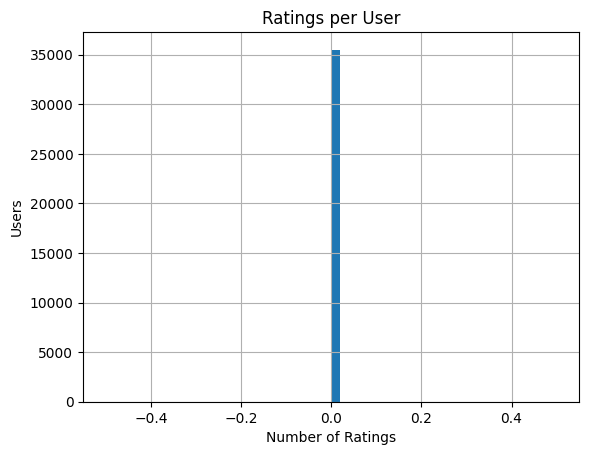

In [4]:
import matplotlib.pyplot as plt

df.groupby('userId')['rating'].count().hist(bins=50)
plt.title("Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Users")
plt.show()

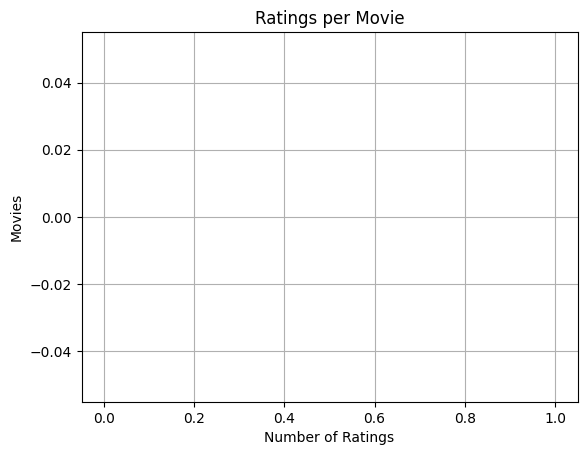

In [5]:
df.groupby('movieId')['rating'].count().hist(bins=50)
plt.title("Ratings per Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Movies")
plt.show()

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

train, test = train_test_split(df, test_size=0.2, random_state=42)

print(train.shape)
print(test.shape)

(28397, 6)
(7100, 6)


In [16]:
print(df.shape)
print(df.columns)
df.head(10)

(35497, 6)
Index(['userId', 'movieId', 'categoryId', 'reviewId', 'rating', 'date'], dtype='object')


,userId,movieId,categoryId,reviewId,rating,date
0,1 1 2,NaN,NaN,NaN,NaN,NaN
1,1 2 4,NaN,NaN,NaN,NaN,NaN
2,1 3 3.5,NaN,NaN,NaN,NaN,NaN
3,1 4 3,NaN,NaN,NaN,NaN,NaN
4,1 5 4,NaN,NaN,NaN,NaN,NaN
5,1 6 3.5,NaN,NaN,NaN,NaN,NaN
6,1 7 3.5,NaN,NaN,NaN,NaN,NaN
7,1 8 3,NaN,NaN,NaN,NaN,NaN
8,1 9 2.5,NaN,NaN,NaN,NaN,NaN
9,1 10 4,NaN,NaN,NaN,NaN,NaN


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35497 entries, 0 to 35496
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   userId   35497 non-null  int64  
 1   movieId  35497 non-null  int64  
 2   rating   35497 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 832.1 KB


In [18]:
df = pd.read_csv(
    "ratings.txt",
    sep=r"\s+",
    header=None,
    names=["userId", "movieId", "rating"]
)

df.head()

,userId,movieId,rating
0,1,1,2.0
1,1,2,4.0
2,1,3,3.5
3,1,4,3.0
4,1,5,4.0


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

train, test = train_test_split(df, test_size=0.2, random_state=42)

In [22]:
global_mean = train['rating'].mean()

test = test.copy()
test['global_pred'] = global_mean

global_rmse = np.sqrt(mean_squared_error(test['rating'], test['global_pred']))
global_mae = mean_absolute_error(test['rating'], test['global_pred'])

print("Global Average RMSE:", global_rmse)
print("Global Average MAE:", global_mae)

Global Average RMSE: 0.9102202131530146
Global Average MAE: 0.7091059658652694


In [23]:
user_means = train.groupby('userId')['rating'].mean()

test['user_pred'] = test['userId'].map(user_means).fillna(global_mean)

user_rmse = np.sqrt(mean_squared_error(test['rating'], test['user_pred']))
user_mae = mean_absolute_error(test['rating'], test['user_pred'])

print("User Average RMSE:", user_rmse)
print("User Average MAE:", user_mae)

User Average RMSE: 0.8211880108728312
User Average MAE: 0.6364672593405465


In [24]:
results = pd.DataFrame({
    "Model": ["Global Average", "User Average"],
    "RMSE": [global_rmse, user_rmse],
    "MAE": [global_mae, user_mae]
})

results

,Model,RMSE,MAE
0,Global Average,0.910220,0.709106
1,User Average,0.821188,0.636467


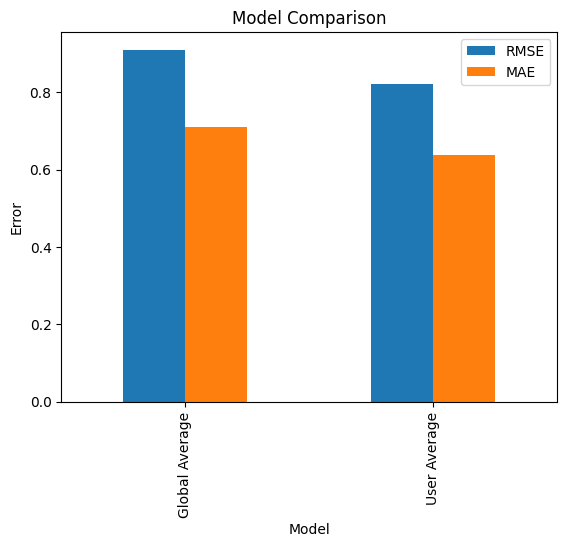

In [25]:
results.plot(x="Model", y=["RMSE", "MAE"], kind="bar")
plt.title("Model Comparison")
plt.ylabel("Error")
plt.show()